In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms
from pathlib import Path
import timm
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report, roc_curve

DATA_DIR  = Path("/kaggle/input/competitions/siim-isic-melanoma-classification")
CSV_PATH  = DATA_DIR / "train.csv"
IMAGE_DIR = DATA_DIR / "jpeg/train"

print("CSV exists:",          CSV_PATH.exists())
print("Image folder exists:", IMAGE_DIR.exists())
print("CUDA available:",      torch.cuda.is_available())

CSV exists: True
Image folder exists: True
CUDA available: True


In [2]:
df = pd.read_csv(CSV_PATH)

print(df.head())
print(df.columns)
print("\nClass distribution:")
print(df["target"].value_counts())

     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  
0   unknown           benign       0  
1   unknown           benign       0  
2     nevus           benign       0  
3   unknown           benign       0  
4   unknown           benign       0  
Index(['image_name', 'patient_id', 'sex', 'age_approx',
       'anatom_site_general_challenge', 'diagnosis', 'benign_malignant',
       'target'],
      dtype='object')

Class distribution:
target
0    32542
1      584
Name: count, dtype: int64


In [3]:
meta_df = df.copy()

# Sex: male -> 1, female -> 0, missing -> 0.5
meta_df["sex"] = meta_df["sex"].map({"male": 1, "female": 0}).fillna(0.5)

# Age: normalise to 0-1, fill missing with median
meta_df["age_approx"] = meta_df["age_approx"].fillna(meta_df["age_approx"].median())
meta_df["age_approx"] = (meta_df["age_approx"] - meta_df["age_approx"].min()) / \
                         (meta_df["age_approx"].max() - meta_df["age_approx"].min())

# Anatomical site: one-hot encode
meta_df["anatom_site_general_challenge"] = \
    meta_df["anatom_site_general_challenge"].fillna("unknown")
site_dummies = pd.get_dummies(
    meta_df["anatom_site_general_challenge"], prefix="site"
).astype(float)
meta_df = pd.concat([meta_df, site_dummies], axis=1)

# n_images per patient: log-scaled count of how many images that patient has
meta_df["n_images"] = meta_df["patient_id"].map(
    meta_df.groupby("patient_id")["image_name"].count()
).fillna(1)
meta_df["n_images"] = np.log1p(meta_df["n_images"].values)

# image_size: log of file size in bytes — proxy for image complexity
meta_df["image_size"] = meta_df["image_name"].apply(
    lambda x: np.log(os.path.getsize(IMAGE_DIR / f"{x}.jpg") + 1)
)

META_FEATURES = ["sex", "age_approx", "n_images", "image_size"] + list(site_dummies.columns)

meta_df[META_FEATURES] = meta_df[META_FEATURES].astype(float)

print("Metadata features:", META_FEATURES)
print("Total features:", len(META_FEATURES))
print(meta_df[META_FEATURES].dtypes)

Metadata features: ['sex', 'age_approx', 'n_images', 'image_size', 'site_head/neck', 'site_lower extremity', 'site_oral/genital', 'site_palms/soles', 'site_torso', 'site_unknown', 'site_upper extremity']
Total features: 11
sex                     float64
age_approx              float64
n_images                float64
image_size              float64
site_head/neck          float64
site_lower extremity    float64
site_oral/genital       float64
site_palms/soles        float64
site_torso              float64
site_unknown            float64
site_upper extremity    float64
dtype: object


In [4]:
train_df, val_df = train_test_split(
    meta_df,
    test_size=0.2,
    stratify=meta_df["target"],
    random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:",   len(val_df))
print("\nTrain class distribution:")
print(train_df["target"].value_counts())

Train size: 26500
Val size: 6626

Train class distribution:
target
0    26033
1      467
Name: count, dtype: int64


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [6]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_dir, feature_cols, transform=None):
        self.dataframe    = dataframe.reset_index(drop=True)
        self.image_dir    = Path(image_dir)
        self.feature_cols = feature_cols
        self.transform    = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row        = self.dataframe.iloc[idx]
        label      = int(row["target"])
        image_path = self.image_dir / f"{row['image_name']}.jpg"
        image      = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        meta = torch.tensor(
            row[self.feature_cols].values.astype(float), dtype=torch.float32
        )

        return image, meta, label

In [7]:
train_set = MelanomaDataset(train_df, IMAGE_DIR, META_FEATURES, transform=train_transform)
val_set   = MelanomaDataset(val_df,   IMAGE_DIR, META_FEATURES, transform=val_transform)

train_loader = DataLoader(
    train_set, batch_size=48, shuffle=True,
    num_workers=4, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_set, batch_size=48, shuffle=False,
    num_workers=4, pin_memory=True, persistent_workers=True
)

print("Train samples:", len(train_set))
print("Val samples:",   len(val_set))
print("Train batches:", len(train_loader))
print("Val batches:",   len(val_loader))

Train samples: 26500
Val samples: 6626
Train batches: 553
Val batches: 139


In [8]:
images, metas, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Meta  batch shape:", metas.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:",   labels[:10])

Image batch shape: torch.Size([48, 3, 320, 320])
Meta  batch shape: torch.Size([48, 11])
Label batch shape: torch.Size([48])
First 10 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [9]:
class MelanomaModel(nn.Module):
    """
    Joint multimodal model:
      - EfficientNet-B3 image backbone  ->  1536-d feature vector
      - Small MLP metadata branch       ->    64-d feature vector
      - Concatenated and passed through fused head  ->  2 logits
    """
    def __init__(self, model_name='efficientnet_b3', meta_dim=9, n_classes=2):
        super().__init__()

        self.backbone = timm.create_model(
            model_name, pretrained=False, num_classes=0, global_pool='avg'
        )
        img_features = self.backbone.num_features  # 1536 for B3

        self.meta_branch = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        fused_dim = img_features + 64
        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(fused_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes),
        )

    def forward(self, image, meta):
        img_feat  = self.backbone(image)
        meta_feat = self.meta_branch(meta)
        fused     = torch.cat([img_feat, meta_feat], dim=1)
        return self.head(fused)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

Using device: cuda


/tmp/ipykernel_23/2805584528.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [11]:
NUM_EPOCHS  = 4
UNFREEZE_AT = 2

class OriginalMelanomaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b3', n_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=True, num_classes=0, global_pool='avg'
        )
        in_features = self.backbone.num_features  # 1536
        self.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

model = OriginalMelanomaModel(n_classes=2).to(device)

# Class-weighted loss
n_neg = (train_df["target"] == 0).sum()
n_pos = (train_df["target"] == 1).sum()
class_weight = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight)

# Phase 1: freeze backbone, only train head
for param in model.backbone.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_auc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    # Phase 2: unfreeze backbone with lower LR
    if epoch == UNFREEZE_AT + 1:
        print(f"Epoch {epoch}: unfreezing backbone")
        for param in model.backbone.parameters():
            param.requires_grad = True
        optimizer = torch.optim.AdamW([
            {"params": model.backbone.parameters(), "lr": 1e-5},
            {"params": model.head.parameters(),     "lr": 1e-4},
        ], weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_AT
        )

    # ── Train ──
    model.train()
    train_losses = []
    for images, metas, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_losses.append(loss.item())
    scheduler.step()

    # ── Validate ──
    model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for images, metas, labels in val_loader:
            with autocast():
                probs = torch.softmax(model(images.to(device)), dim=1)[:, 1]
            val_probs.extend(probs.cpu().float().numpy())
            val_labels.extend(labels.numpy())

    auc = roc_auc_score(val_labels, val_probs)
    print(f"Epoch {epoch:2d} | Loss: {np.mean(train_losses):.4f} | Val AUC: {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_model_finetuned.pth")
        print(f"  ✓ Saved (best AUC: {best_auc:.4f})")

print(f"\nTraining complete. Best AUC: {best_auc:.4f}")

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

/tmp/ipykernel_23/1808324311.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23/1808324311.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  1 | Loss: 0.6025 | Val AUC: 0.7955
  ✓ Saved (best AUC: 0.7955)


/tmp/ipykernel_23/1808324311.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23/1808324311.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  2 | Loss: 0.5346 | Val AUC: 0.8131
  ✓ Saved (best AUC: 0.8131)
Epoch 3: unfreezing backbone


/tmp/ipykernel_23/1808324311.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23/1808324311.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  3 | Loss: 0.5062 | Val AUC: 0.8240
  ✓ Saved (best AUC: 0.8240)


/tmp/ipykernel_23/1808324311.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23/1808324311.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch  4 | Loss: 0.4610 | Val AUC: 0.8231

Training complete. Best AUC: 0.8240


In [12]:
META_CKPT_V2 = "best_meta_model_v2.pth"

# ── Original image-only architecture (matches the saved .pth exactly) ─────────
class OriginalMelanomaModel(nn.Module):
    def __init__(self, model_name='efficientnet_b3', n_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=False, num_classes=0, global_pool='avg'
        )
        in_features = self.backbone.num_features  # 1536
        self.head = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


# ── Metadata MLP ───────────────────────────────────────────────────────────────
class MetadataModel(nn.Module):
    def __init__(self, input_dim, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes)
        )
    def forward(self, x):
        return self.net(x)


# ── Retrain metadata model with the new feature set ───────────────────────────
X_train = torch.tensor(train_df[META_FEATURES].values.astype(float), dtype=torch.float32)
y_train = torch.tensor(train_df["target"].values, dtype=torch.long)
X_val   = torch.tensor(val_df[META_FEATURES].values.astype(float),   dtype=torch.float32)
y_val   = torch.tensor(val_df["target"].values,   dtype=torch.long)

meta_train_loader_tab = DataLoader(TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
meta_val_loader_tab   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=256, shuffle=False)

n_neg = (y_train == 0).sum().item()
n_pos = (y_train == 1).sum().item()
class_weight = torch.tensor([1.0, n_neg / n_pos], dtype=torch.float32).to(device)

new_meta_model = MetadataModel(input_dim=len(META_FEATURES)).to(device)
meta_optimizer = torch.optim.AdamW(new_meta_model.parameters(), lr=1e-3, weight_decay=1e-4)
meta_criterion = nn.CrossEntropyLoss(weight=class_weight)

best_meta_auc = 0.0
for epoch in range(1, 31):
    new_meta_model.train()
    for feats, labels in meta_train_loader_tab:
        feats, labels = feats.to(device), labels.to(device)
        meta_optimizer.zero_grad()
        loss = meta_criterion(new_meta_model(feats), labels)
        loss.backward()
        meta_optimizer.step()

    new_meta_model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for feats, labels in meta_val_loader_tab:
            probs = torch.softmax(new_meta_model(feats.to(device)), dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(labels.numpy())
    auc = roc_auc_score(val_labels, val_probs)
    if auc > best_meta_auc:
        best_meta_auc = auc
        torch.save(new_meta_model.state_dict(), META_CKPT_V2)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} — Val AUC: {auc:.4f}  (best: {best_meta_auc:.4f})")

print(f"\nMetadata model retrained ✓  Best AUC: {best_meta_auc:.4f}")
print(f"Saved to {META_CKPT_V2}")

Epoch  5 — Val AUC: 0.6961  (best: 0.6961)
Epoch 10 — Val AUC: 0.7127  (best: 0.7127)
Epoch 15 — Val AUC: 0.7307  (best: 0.7307)
Epoch 20 — Val AUC: 0.7414  (best: 0.7414)
Epoch 25 — Val AUC: 0.7567  (best: 0.7567)
Epoch 30 — Val AUC: 0.7656  (best: 0.7674)

Metadata model retrained ✓  Best AUC: 0.7674
Saved to best_meta_model_v2.pth


In [13]:
IMAGE_CKPT = "/kaggle/input/datasets/louisilett/version-7-output/best_model_efficientnet_b3.pth"

# Load freshly trained image model
image_model = OriginalMelanomaModel(n_classes=2).to(device)
image_model.load_state_dict(torch.load("best_model_finetuned.pth", map_location=device), strict=True)
image_model.eval()
print("Image model loaded ✓")

# Load freshly retrained metadata model
meta_model = MetadataModel(input_dim=len(META_FEATURES)).to(device)
meta_model.load_state_dict(torch.load(META_CKPT_V2, map_location=device), strict=True)
meta_model.eval()
print("Metadata model loaded ✓")

Image model loaded ✓
Metadata model loaded ✓


In [14]:
N_TTA = 8

def tta_transform(images, i):
    """Apply the i-th TTA transform to a batch of images [B, C, H, W]."""
    if i >= 4:
        images = images.transpose(2, 3)
    if i % 4 == 0:   return images
    elif i % 4 == 1: return images.flip(2)
    elif i % 4 == 2: return images.flip(3)
    elif i % 4 == 3: return images.flip(2).flip(3)

image_probs, meta_probs_list, true_labels = [], [], []

image_model.eval()
meta_model.eval()

with torch.no_grad():
    for images, metas, labels in val_loader:
        images = images.to(device, non_blocking=True)
        metas  = metas.to(device, non_blocking=True)

        tta_probs = torch.zeros(images.size(0), 2, device=device)
        for i in range(N_TTA):
            aug_images = tta_transform(images, i)
            logits     = image_model(aug_images)
            tta_probs += torch.softmax(logits, dim=1)
        tta_probs /= N_TTA
        img_p = tta_probs[:, 1]

        meta_logits = meta_model(metas)
        meta_p      = torch.softmax(meta_logits, dim=1)[:, 1]

        image_probs.extend(img_p.cpu().numpy())
        meta_probs_list.extend(meta_p.cpu().numpy())
        true_labels.extend(labels.numpy())

image_probs    = np.array(image_probs)
meta_probs_arr = np.array(meta_probs_list)
true_labels    = np.array(true_labels)

image_auc = roc_auc_score(true_labels, image_probs)
meta_auc  = roc_auc_score(true_labels, meta_probs_arr)
print(f"Image model AUC (TTA x{N_TTA}): {image_auc:.4f}")
print(f"Metadata model AUC:             {meta_auc:.4f}")

Image model AUC (TTA x8): 0.8343
Metadata model AUC:             0.7674


Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.85      0.92      6509
    Melanoma       0.07      0.64      0.13       117

    accuracy                           0.85      6626
   macro avg       0.53      0.75      0.52      6626
weighted avg       0.98      0.85      0.90      6626


Image model AUC:    0.8343
Metadata model AUC: 0.7674
Ensemble AUC:       0.8453
Improvement:        +0.0110


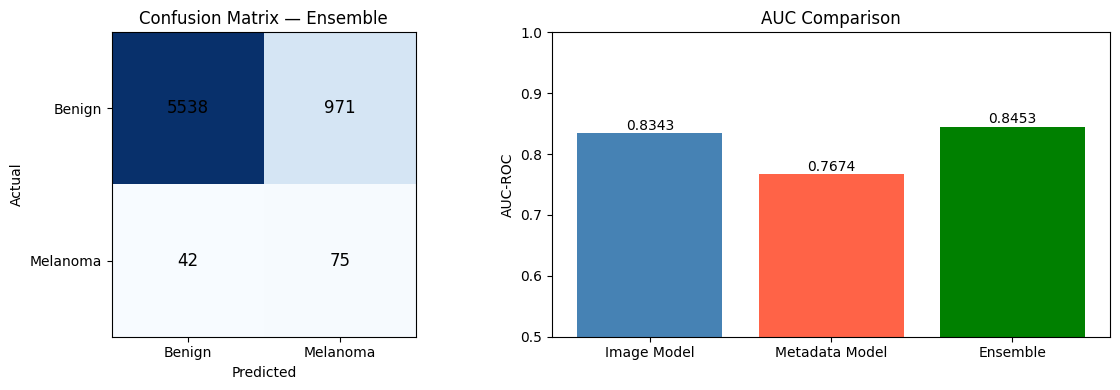

In [15]:
IMAGE_WEIGHT    = 0.8
METADATA_WEIGHT = 0.2
ensemble_probs  = IMAGE_WEIGHT * image_probs + METADATA_WEIGHT * meta_probs_arr
ensemble_auc    = roc_auc_score(true_labels, ensemble_probs)
ensemble_preds  = (ensemble_probs >= 0.5).astype(int)
cm              = confusion_matrix(true_labels, ensemble_preds)

print("Classification Report:")
print(classification_report(true_labels, ensemble_preds, target_names=["Benign", "Melanoma"]))
print(f"\nImage model AUC:    {image_auc:.4f}")
print(f"Metadata model AUC: {meta_auc:.4f}")
print(f"Ensemble AUC:       {ensemble_auc:.4f}")
print(f"Improvement:        +{ensemble_auc - image_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix — Ensemble")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Benign", "Melanoma"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Benign", "Melanoma"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

axes[1].bar(
    ["Image Model", "Metadata Model", "Ensemble"],
    [image_auc, meta_auc, ensemble_auc],
    color=["steelblue", "tomato", "green"]
)
axes[1].set_title("AUC Comparison")
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim([0.5, 1.0])
for i, v in enumerate([image_auc, meta_auc, ensemble_auc]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

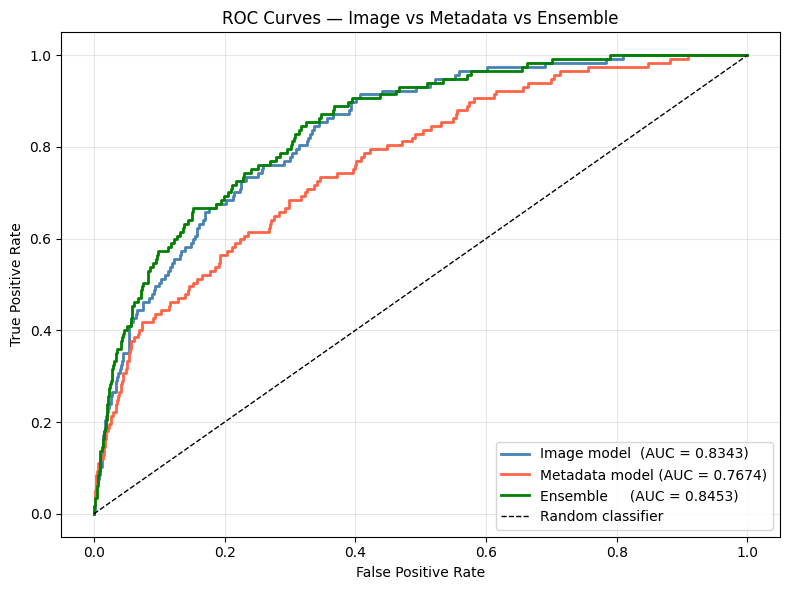

ROC curve saved to roc_curve.png


In [16]:
fpr_img,  tpr_img,  _ = roc_curve(true_labels, image_probs)
fpr_meta, tpr_meta, _ = roc_curve(true_labels, meta_probs_arr)
fpr_ens,  tpr_ens,  _ = roc_curve(true_labels, ensemble_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_img,  tpr_img,  label=f"Image model  (AUC = {image_auc:.4f})",    color="steelblue", lw=2)
plt.plot(fpr_meta, tpr_meta, label=f"Metadata model (AUC = {meta_auc:.4f})",   color="tomato",    lw=2)
plt.plot(fpr_ens,  tpr_ens,  label=f"Ensemble     (AUC = {ensemble_auc:.4f})", color="green",     lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Image vs Metadata vs Ensemble")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()
print("ROC curve saved to roc_curve.png")

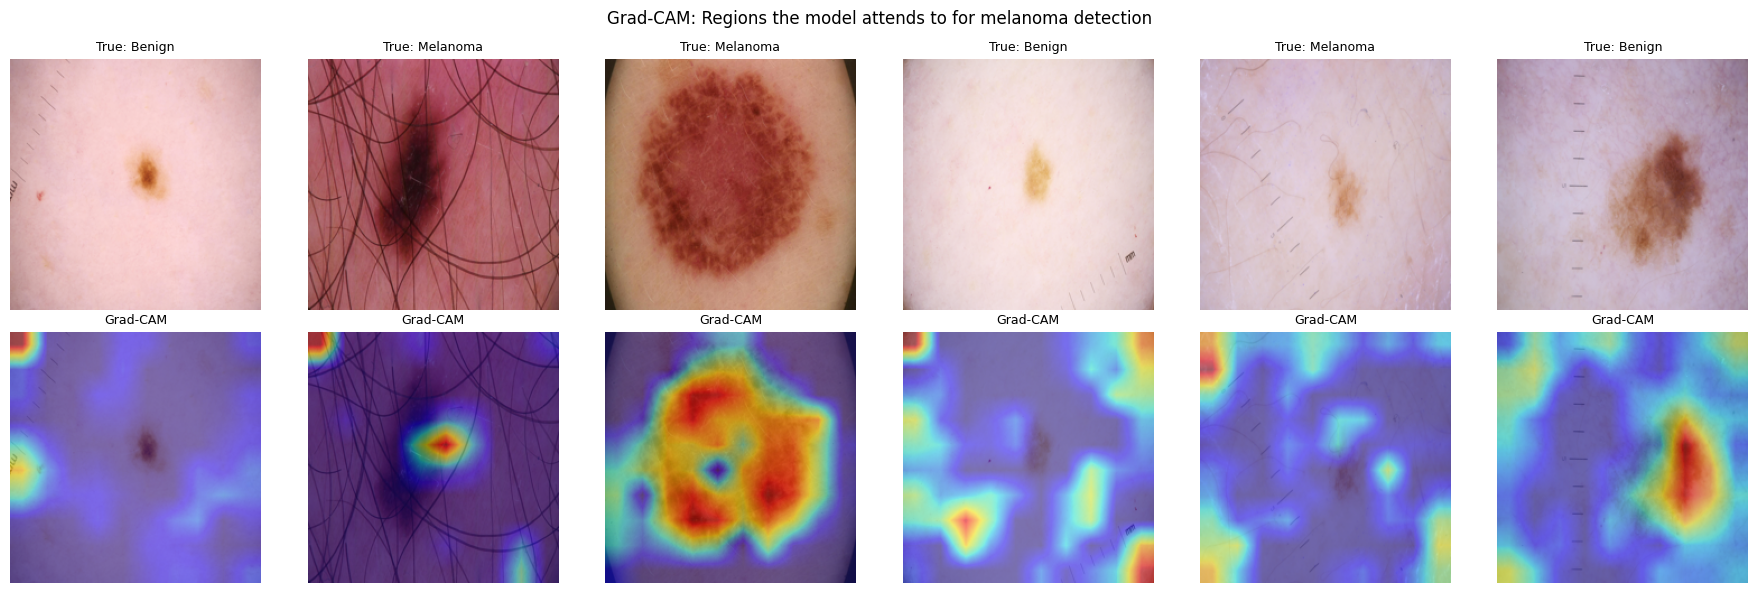

Grad-CAM saved to gradcam.png


In [17]:
def get_gradcam(model, image_tensor, target_class=1):
    model.eval()
    gradients, activations = [], []

    target_layer = model.backbone.blocks[-1]

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    logits       = model(image_tensor)

    model.zero_grad()
    logits[0, target_class].backward()

    fh.remove(); bh.remove()

    grads   = gradients[0]
    acts    = activations[0]
    weights = grads.mean(dim=[2, 3], keepdim=True)
    cam     = (weights * acts).sum(dim=1).squeeze()
    cam     = F.relu(cam)
    cam     = cam - cam.min()
    cam     = cam / (cam.max() + 1e-8)
    return cam.detach().cpu().numpy()


def show_gradcam(model, val_df, val_transform, n_samples=6):
    melanoma_rows = val_df[val_df["target"] == 1].sample(n_samples // 2, random_state=0)
    benign_rows   = val_df[val_df["target"] == 0].sample(n_samples // 2, random_state=0)
    samples       = pd.concat([melanoma_rows, benign_rows]).sample(frac=1, random_state=0)

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))

    for col, (_, row) in enumerate(samples.iterrows()):
        img_path = IMAGE_DIR / f"{row['image_name']}.jpg"
        orig_img = Image.open(img_path).convert("RGB").resize((224, 224))
        img_tensor = val_transform(orig_img)

        cam = get_gradcam(model, img_tensor, target_class=1)

        import cv2
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap     = plt.cm.jet(cam_resized)[:, :, :3]
        overlay     = np.array(orig_img) / 255.0 * 0.5 + heatmap * 0.5

        true_label = "Melanoma" if row["target"] == 1 else "Benign"
        axes[0, col].imshow(orig_img)
        axes[0, col].set_title(f"True: {true_label}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(overlay)
        axes[1, col].set_title("Grad-CAM", fontsize=9)
        axes[1, col].axis("off")

    plt.suptitle("Grad-CAM: Regions the model attends to for melanoma detection", fontsize=12)
    plt.tight_layout()
    plt.savefig("gradcam.png", dpi=150)
    plt.show()
    print("Grad-CAM saved to gradcam.png")


show_gradcam(image_model, val_df, val_transform, n_samples=6)